# IronClad Task 2: MTCNN Face Cropping

This notebook extends the model-selection analysis of the Task 1 notebook by introducing MTCNN (Multi-task Cascaded Convolutional Networks) as an additional face detection and cropping stage before embedding extraction. The goal is to determine whether explicitly localizing and cropping the facial region improves identification performance relative to the baseline pipeline, which only resizes and normalizes the original image. 

The notebook compares two preprocessing variants (baseline and confidence-aware MTCNN cropping with fallback) under the same evaluation protocol used in Task 1: both backbones (casia-webface and vggface2), the three primary exact metrics (Euclidean, cosine, dot product), and the same noise perturbation grid (Gaussian blur, resizing, brightness), all evaluated under exact Brute Force retrieval. A preliminary threshold sweep selects the MTCNN confidence level above which a detection is trusted; below that threshold, the pipeline falls back to the original image. 

The notebook reports clean and noisy Top-1/Top-3/Top-5 accuracy, Mean Reciprocal Rank, and direct baseline-versus-MTCNN deltas, and checks whether the model ranking from Task 1 remains stable under the redesigned preprocessing. 

A supplementary Minkowski analysis is included.

### Imports and settings

In [1]:

import sys, subprocess, importlib, types
from pathlib import Path

def ensure(import_name: str, pip_name: str = None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"{import_name} already installed")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        importlib.import_module(import_name)
        print(f"Installed {import_name}")

ensure("faiss", "faiss-cpu")
ensure("tqdm", "tqdm")
ensure("facenet_pytorch", "facenet-pytorch")

# Compatibility shim for some older checkpoints
if "torch.utils.serialization" not in sys.modules:
    sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")

import os
import json
import math
import time
import random
import hashlib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from PIL import Image, ImageFilter, ImageEnhance, UnidentifiedImageError

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

import faiss
from facenet_pytorch import MTCNN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available(), "| DEVICE:", DEVICE)
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)


faiss already installed
tqdm already installed
facenet_pytorch already installed
CUDA available: False | DEVICE: cpu


In [2]:
# Project imports
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main


## Load IronClad gallery/probe data

Expected structure:
```text
BASE/
  ironclad/
    storage/
      gallery/<Identity>/*
      probe/<Identity>/*
```


In [3]:

STORAGE_ROOT = PROJECT_ROOT / "ironclad" / "storage"
GALLERY_DIR = STORAGE_ROOT / "gallery"
PROBE_DIR = STORAGE_ROOT / "probe"

print("Storage root:", STORAGE_ROOT)
print("Gallery dir :", GALLERY_DIR)
print("Probe dir   :", PROBE_DIR)

if not (GALLERY_DIR.exists() and PROBE_DIR.exists()):
    raise FileNotFoundError("Expected BASE/ironclad/storage/gallery and probe")

def list_images_by_identity(base_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    out = {}
    for ident_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        imgs = []
        for p in ident_dir.rglob("*"):
            if not p.is_file():
                continue
            if p.suffix.lower() not in exts:
                continue
            if p.name.startswith("._") or p.name.startswith("."):
                continue
            imgs.append(p)
        if imgs:
            out[ident_dir.name] = sorted(imgs)
    return out

gallery = list_images_by_identity(GALLERY_DIR)
probe = list_images_by_identity(PROBE_DIR)
overlap = sorted(set(gallery.keys()) & set(probe.keys()))

print("Identities in gallery:", len(gallery))
print("Identities in probe  :", len(probe))
print("Overlap identities   :", len(overlap))
print("Example overlap      :", overlap[:5])

gallery_paths, gallery_labels = [], []
for ident in overlap:
    for p in gallery[ident]:
        gallery_paths.append(p)
        gallery_labels.append(ident)

probe_paths, probe_labels = [], []
for ident in overlap:
    for p in probe[ident]:
        probe_paths.append(p)
        probe_labels.append(ident)

print("Gallery images:", len(gallery_paths))
print("Probe images  :", len(probe_paths))


Storage root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage
Gallery dir : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\gallery
Probe dir   : C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\ironclad\storage\probe
Identities in gallery: 1000
Identities in probe  : 999
Overlap identities   : 999
Example overlap      : ['Aaron_Sorkin', 'Abdel_Nasser_Assidi', 'Abdullah', 'Abdullah_Gul', 'Abdullah_al-Attiyah']
Gallery images: 2261
Probe images  : 999


## Configuration

We mirror the enhanced Task 1 setup:

- models: `casia-webface`, `vggface2`
- exact metrics: `euclidean`, `cosine`, `dot_product`
- exact retrieval: **Brute Force**
- noise settings: Gaussian blur, resize, brightness

For the new preprocessing stage, we compare:

- `baseline`
- `mtcnn_conf` (confidence-aware crop with fallback)

There is also a short threshold-selection section to choose the MTCNN confidence threshold used in the main experiments.


In [4]:

MODELS = ["casia-webface", "vggface2"]
EXACT_METRICS = ["euclidean", "cosine", "dot_product"]

# Optional supplementary metric
RUN_MINKOWSKI = False
MINKOWSKI_P = 3

DEFAULT_IMAGE_SIZE = 160
MTCNN_MARGIN_PX = 20

# Threshold candidates for clean cosine selection
THRESHOLD_CANDIDATES = [0.5, 0.6, 0.7, 0.80, 0.90, 0.95]
DEFAULT_THRESHOLD = 0.90

NOISE_PLAN = {
    "gaussian_blur": [1.0, 2.0, 3.0],
    "resize": [0.35, 0.50, 0.75],
    "brightness": [0.60, 0.80, 1.20, 1.40],
}


## Image helpers, noise transforms, and MTCNN detection cache

In [5]:

preproc = Preprocessing(image_size=DEFAULT_IMAGE_SIZE)
CACHE_DIR = Path.cwd() / "cache_mtcnn_task1"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DETECTION_CACHE_FILE = CACHE_DIR / "mtcnn_detection_cache.json"

def pil_load_rgb(path: Path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError):
        return None

def apply_noise(img: Image.Image, noise_type: str, noise_level: float) -> Image.Image:
    if noise_type == "none":
        return img

    if noise_type == "gaussian_blur":
        return img.filter(ImageFilter.GaussianBlur(radius=float(noise_level)))

    if noise_type == "resize":
        scale = float(noise_level)
        w, h = img.size
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        small = img.resize((new_w, new_h), Image.BILINEAR)
        return small.resize((w, h), Image.BILINEAR)

    if noise_type == "brightness":
        enhancer = ImageEnhance.Brightness(img)
        return enhancer.enhance(float(noise_level))

    raise ValueError(f"Unsupported noise_type: {noise_type}")

def _path_key(path: Path) -> str:
    return str(path.resolve())

# Initialize detector once
mtcnn = MTCNN(
    image_size=DEFAULT_IMAGE_SIZE,
    margin=MTCNN_MARGIN_PX,
    keep_all=True,
    device=DEVICE
)

# Load or initialize detection cache
if DETECTION_CACHE_FILE.exists():
    with open(DETECTION_CACHE_FILE, "r", encoding="utf-8") as f:
        DETECTION_CACHE = json.load(f)
    print("Loaded detection cache entries:", len(DETECTION_CACHE))
else:
    DETECTION_CACHE = {}
    print("Starting empty detection cache")

def save_detection_cache():
    with open(DETECTION_CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(DETECTION_CACHE, f)

def detect_face_box_clean(path: Path):
    """
    Detect the best face box on the CLEAN image only and cache it.

    Returns:
        dict with keys:
            found: bool
            prob: float or None
            box: [x1,y1,x2,y2] or None
    """
    key = _path_key(path)
    if key in DETECTION_CACHE:
        return DETECTION_CACHE[key]

    img = pil_load_rgb(path)
    if img is None:
        result = {"found": False, "prob": None, "box": None}
        DETECTION_CACHE[key] = result
        return result

    boxes, probs = mtcnn.detect(img)

    if boxes is None or probs is None or len(boxes) == 0:
        result = {"found": False, "prob": None, "box": None}
    else:
        probs = np.array(probs, dtype=np.float32)
        best_idx = int(np.argmax(probs))
        best_box = boxes[best_idx].tolist()
        best_prob = float(probs[best_idx])
        result = {"found": True, "prob": best_prob, "box": best_box}

    DETECTION_CACHE[key] = result
    return result

def crop_with_box(img: Image.Image, box, margin_px: int = 20) -> Image.Image:
    w, h = img.size
    x1, y1, x2, y2 = box
    x1 = max(0, int(math.floor(x1)) - margin_px)
    y1 = max(0, int(math.floor(y1)) - margin_px)
    x2 = min(w, int(math.ceil(x2)) + margin_px)
    y2 = min(h, int(math.ceil(y2)) + margin_px)
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def prepare_image(path: Path, variant: str = "baseline", conf_threshold: float = 0.90,
                  noise_type: str = "none", noise_level: float = 0.0,
                  margin_px: int = 20) -> Image.Image:
    """
    Prepare image for embedding:
      - load clean image
      - apply requested synthetic noise
      - optionally crop using cached clean-image MTCNN detection
    """
    img = pil_load_rgb(path)
    if img is None:
        return None

    # Apply noise first to the current image
    img = apply_noise(img, noise_type, noise_level)

    if variant == "baseline":
        return img

    det = detect_face_box_clean(path)

    if not det["found"] or det["box"] is None:
        return img  # fallback

    if variant == "mtcnn_always":
        return crop_with_box(img, det["box"], margin_px=margin_px)

    if variant == "mtcnn_conf":
        prob = det["prob"] if det["prob"] is not None else 0.0
        if prob >= float(conf_threshold):
            return crop_with_box(img, det["box"], margin_px=margin_px)
        return img  # fallback if confidence too low

    raise ValueError(f"Unknown variant: {variant}")

def l2_normalize(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    return X / norms

# Cache clean detections once for all dataset images
all_paths = sorted(set(gallery_paths + probe_paths))
for p in tqdm(all_paths, desc="Caching clean-image MTCNN detections"):
    detect_face_box_clean(p)
save_detection_cache()
print("Detection cache saved:", DETECTION_CACHE_FILE)


Loaded detection cache entries: 3260


Caching clean-image MTCNN detections:   0%|          | 0/3260 [00:00<?, ?it/s]

Detection cache saved: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main\analysis\cache_mtcnn_task1\mtcnn_detection_cache.json


## Detection statistics

In [6]:

def detection_stats(paths):
    rows = []
    for p in paths:
        det = detect_face_box_clean(p)
        rows.append({
            "path": str(p),
            "found": det["found"],
            "prob": det["prob"] if det["prob"] is not None else np.nan
        })
    df = pd.DataFrame(rows)
    out = {
        "n_images": len(df),
        "detection_rate": float(df["found"].mean()) if len(df) else float("nan"),
        "mean_confidence_detected": float(df.loc[df["found"], "prob"].mean()) if df["found"].any() else float("nan"),
        "median_confidence_detected": float(df.loc[df["found"], "prob"].median()) if df["found"].any() else float("nan"),
    }
    return pd.DataFrame([out])

gallery_det_stats = detection_stats(gallery_paths)
probe_det_stats = detection_stats(probe_paths)

print("Gallery detection stats")
display(gallery_det_stats)
print("Probe detection stats")
display(probe_det_stats)


Gallery detection stats


,n_images,detection_rate,mean_confidence_detected,median_confidence_detected
0,2261,0.999558,0.999689,0.999968


Probe detection stats


,n_images,detection_rate,mean_confidence_detected,median_confidence_detected
0,999,1.0,0.999543,0.999964


## Embedding cache

We cache embeddings by:

- model
- preprocessing variant
- confidence threshold
- split / descriptor
- noise type / level

In [7]:

def cache_name_for_embedding(model_name: str, variant: str, conf_threshold: float,
                             desc: str, noise_type: str, noise_level: float) -> Path:
    key = f"{model_name}|{variant}|{conf_threshold:.3f}|{desc}|{noise_type}|{noise_level}"
    digest = hashlib.md5(key.encode("utf-8")).hexdigest()[:12]
    return CACHE_DIR / f"emb_{model_name}_{variant}_{desc}_{noise_type}_{noise_level}_{digest}.npz"

def compute_embeddings(model_name: str, image_paths, desc: str,
                       variant: str = "baseline", conf_threshold: float = 0.90,
                       noise_type: str = "none", noise_level: float = 0.0) -> np.ndarray:
    cache_path = cache_name_for_embedding(
        model_name=model_name,
        variant=variant,
        conf_threshold=conf_threshold,
        desc=desc,
        noise_type=noise_type,
        noise_level=noise_level
    )
    if cache_path.exists():
        z = np.load(cache_path)
        return z["X"].astype(np.float32)

    emb_model = Embedding(pretrained=model_name, device=DEVICE)
    vecs = []
    for p in tqdm(image_paths, desc=f"Embeddings {model_name} | {variant} | {desc} | {noise_type}:{noise_level}"):
        img = prepare_image(
            p,
            variant=variant,
            conf_threshold=conf_threshold,
            noise_type=noise_type,
            noise_level=noise_level,
            margin_px=MTCNN_MARGIN_PX
        )
        if img is None:
            continue
        tens = preproc.process(img)
        vec = emb_model.encode(tens).astype(np.float32)
        vecs.append(vec)

    X = np.vstack(vecs).astype(np.float32)
    np.savez(cache_path, X=X)
    return X


## Batch evaluation helpers

We mirror the enhanced Task 1 reporting:

- clean **Top-1 / Top-3 / Top-5**
- noisy **Top-1**
- summary by average / worst noisy Top-1


In [8]:

def prepare_query_matrix(Q: np.ndarray, metric: str) -> np.ndarray:
    Q = np.asarray(Q, dtype=np.float32)
    if metric == "cosine":
        return l2_normalize(Q)
    return Q

def topk_identity_accuracy(index_obj, Q: np.ndarray, true_labels, metric: str, k_values=(1,3,5)):
    Qp = prepare_query_matrix(Q, metric)
    kmax = max(k_values)
    D, I = index_obj.index.search(Qp.astype(np.float32), kmax)

    rows = []
    for k in k_values:
        correct = 0
        for qi, true_lab in enumerate(true_labels):
            preds = [index_obj.get_metadata(int(j)) for j in I[qi, :k] if int(j) >= 0]
            if true_lab in preds:
                correct += 1
        rows.append({"k": k, "accuracy": correct / len(true_labels)})
    return pd.DataFrame(rows)

def evaluate_clean(model_name: str, metric: str, variant: str, conf_threshold: float,
                   k_values=(1,3,5)) -> pd.DataFrame:
    gal_X = compute_embeddings(model_name, gallery_paths, "gallery_clean", variant, conf_threshold, "none", 0.0)
    prb_X = compute_embeddings(model_name, probe_paths, "probe_clean", variant, conf_threshold, "none", 0.0)

    bf = FaissBruteForce(dim=gal_X.shape[1], metric=metric)
    bf.add_embeddings(gal_X, gallery_labels)

    res = topk_identity_accuracy(bf, prb_X, probe_labels, metric=metric, k_values=k_values)
    res["model"] = model_name
    res["metric"] = metric
    res["variant"] = variant
    res["conf_threshold"] = conf_threshold
    return res

def evaluate_noisy_top1(model_name: str, metric: str, variant: str, conf_threshold: float,
                        noise_type: str, noise_level: float) -> pd.DataFrame:
    gal_X = compute_embeddings(model_name, gallery_paths, "gallery_clean", variant, conf_threshold, "none", 0.0)
    prb_X = compute_embeddings(model_name, probe_paths, f"probe_{noise_type}_{noise_level}", variant,
                               conf_threshold, noise_type, noise_level)

    bf = FaissBruteForce(dim=gal_X.shape[1], metric=metric)
    bf.add_embeddings(gal_X, gallery_labels)

    res = topk_identity_accuracy(bf, prb_X, probe_labels, metric=metric, k_values=(1,))
    top1 = float(res.loc[res["k"] == 1, "accuracy"].iloc[0])

    return pd.DataFrame([{
        "model": model_name,
        "metric": metric,
        "variant": variant,
        "conf_threshold": conf_threshold,
        "noise_type": noise_type,
        "noise_level": noise_level,
        "top1": top1
    }])


def reciprocal_rank_identity(index_obj, Q: np.ndarray, true_labels, metric: str) -> pd.DataFrame:
    Qp = prepare_query_matrix(Q, metric)
    kmax = len(index_obj.metadata)
    D, I = index_obj.index.search(Qp.astype(np.float32), kmax)

    reciprocal = []
    for qi, true_lab in enumerate(true_labels):
        preds = [index_obj.get_metadata(int(j)) for j in I[qi, :] if int(j) >= 0]
        rank = 0
        for idx, pred in enumerate(preds, start=1):
            if pred == true_lab:
                rank = idx
                break
        reciprocal.append(0.0 if rank == 0 else 1.0 / rank)
    return pd.DataFrame([{"mrr": float(np.mean(reciprocal)) if reciprocal else np.nan}])

def evaluate_clean_mrr(model_name: str, metric: str, variant: str, conf_threshold: float) -> pd.DataFrame:
    gal_X = compute_embeddings(model_name, gallery_paths, "gallery_clean", variant, conf_threshold, "none", 0.0)
    prb_X = compute_embeddings(model_name, probe_paths, "probe_clean", variant, conf_threshold, "none", 0.0)

    bf = FaissBruteForce(dim=gal_X.shape[1], metric=metric)
    bf.add_embeddings(gal_X, gallery_labels)

    res = reciprocal_rank_identity(bf, prb_X, probe_labels, metric=metric)
    res["model"] = model_name
    res["metric"] = metric
    res["variant"] = variant
    res["conf_threshold"] = conf_threshold
    return res

def evaluate_noisy_mrr(model_name: str, metric: str, variant: str, conf_threshold: float,
                       noise_type: str, noise_level: float) -> pd.DataFrame:
    gal_X = compute_embeddings(model_name, gallery_paths, "gallery_clean", variant, conf_threshold, "none", 0.0)
    prb_X = compute_embeddings(model_name, probe_paths, f"probe_{noise_type}_{noise_level}", variant,
                               conf_threshold, noise_type, noise_level)

    bf = FaissBruteForce(dim=gal_X.shape[1], metric=metric)
    bf.add_embeddings(gal_X, gallery_labels)

    res = reciprocal_rank_identity(bf, prb_X, probe_labels, metric=metric)
    return pd.DataFrame([{
        "model": model_name,
        "metric": metric,
        "variant": variant,
        "conf_threshold": conf_threshold,
        "noise_type": noise_type,
        "noise_level": noise_level,
        "mrr": float(res["mrr"].iloc[0])
    }])


## Threshold selection for confidence-aware cropping


In [9]:

threshold_rows = []
for model_name in MODELS:
    for thr in THRESHOLD_CANDIDATES:
        df_thr = evaluate_clean(model_name, "cosine", "mtcnn_conf", thr, k_values=(1,))
        top1 = float(df_thr.loc[df_thr["k"] == 1, "accuracy"].iloc[0])
        threshold_rows.append({
            "model": model_name,
            "threshold": thr,
            "clean_top1_cosine": top1
        })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

# Choose threshold by mean clean cosine Top-1 across the two models.
thr_summary = (
    threshold_df
    .groupby("threshold", as_index=False)["clean_top1_cosine"]
    .mean()
    .sort_values("threshold")
    .reset_index(drop=True)
)
display(thr_summary)

best_score = thr_summary["clean_top1_cosine"].max()
tol = 1e-12

SELECTED_THRESHOLD = float(
    thr_summary.loc[
        thr_summary["clean_top1_cosine"] >= best_score - tol,
        "threshold"
    ].max()
) if len(thr_summary) else DEFAULT_THRESHOLD

print("Selected threshold:", SELECTED_THRESHOLD)


,model,threshold,clean_top1_cosine
0,casia-webface,0.50,0.777778
1,casia-webface,0.60,0.777778
2,casia-webface,0.70,0.777778
3,casia-webface,0.80,0.777778
4,casia-webface,0.90,0.776777
5,casia-webface,0.95,0.776777
6,vggface2,0.50,0.842843
7,vggface2,0.60,0.842843
8,vggface2,0.70,0.842843
9,vggface2,0.80,0.842843


,threshold,clean_top1_cosine
0,0.50,0.81031
1,0.60,0.81031
2,0.70,0.81031
3,0.80,0.81031
4,0.90,0.80981
5,0.95,0.80981


Selected threshold: 0.8


## Evaluation

We now run the full enhanced Task 1 style comparison for:

- both models
- all exact metrics
- both preprocessing variants:
  - `baseline`
  - `mtcnn_conf` with the selected threshold


In [10]:

VARIANTS = [
    ("baseline", DEFAULT_THRESHOLD),
    ("mtcnn_conf", SELECTED_THRESHOLD),
]

clean_rows = []
for model_name in MODELS:
    for metric in EXACT_METRICS:
        for variant, thr in VARIANTS:
            dfc = evaluate_clean(model_name, metric, variant, thr, k_values=(1,3,5))
            clean_rows.append(dfc)

clean_df = pd.concat(clean_rows, ignore_index=True)
clean_df


,k,accuracy,model,metric,variant,conf_threshold
0,1,0.093093,casia-webface,euclidean,baseline,0.9
1,3,0.137137,casia-webface,euclidean,baseline,0.9
2,5,0.163163,casia-webface,euclidean,baseline,0.9
3,1,0.777778,casia-webface,euclidean,mtcnn_conf,0.8
4,3,0.833834,casia-webface,euclidean,mtcnn_conf,0.8
5,5,0.854855,casia-webface,euclidean,mtcnn_conf,0.8
6,1,0.093093,casia-webface,cosine,baseline,0.9
7,3,0.137137,casia-webface,cosine,baseline,0.9
8,5,0.163163,casia-webface,cosine,baseline,0.9
9,1,0.777778,casia-webface,cosine,mtcnn_conf,0.8


In [11]:

noise_rows = []
for model_name in MODELS:
    for metric in EXACT_METRICS:
        for variant, thr in VARIANTS:
            for noise_type, levels in NOISE_PLAN.items():
                for level in levels:
                    dfn = evaluate_noisy_top1(model_name, metric, variant, thr, noise_type, float(level))
                    noise_rows.append(dfn)

noise_df = pd.concat(noise_rows, ignore_index=True)
noise_df


,model,metric,variant,conf_threshold,noise_type,noise_level,top1
0,casia-webface,euclidean,baseline,0.9,gaussian_blur,1.00,0.092092
1,casia-webface,euclidean,baseline,0.9,gaussian_blur,2.00,0.059059
2,casia-webface,euclidean,baseline,0.9,gaussian_blur,3.00,0.032032
3,casia-webface,euclidean,baseline,0.9,resize,0.35,0.074074
4,casia-webface,euclidean,baseline,0.9,resize,0.50,0.088088
5,casia-webface,euclidean,baseline,0.9,resize,0.75,0.098098
6,casia-webface,euclidean,baseline,0.9,brightness,0.60,0.029029
7,casia-webface,euclidean,baseline,0.9,brightness,0.80,0.078078
8,casia-webface,euclidean,baseline,0.9,brightness,1.20,0.068068
9,casia-webface,euclidean,baseline,0.9,brightness,1.40,0.055055


## Mean Reciprocal Rank (MRR)

We add **MRR** as a complementary ranking metric. For each probe, MRR rewards placing the first correct identity as early as possible in the ranked identity list, and we summarize both clean and noisy MRR in the same way as Top-1.

In [12]:

clean_mrr_rows = []
for model_name in MODELS:
    for metric in EXACT_METRICS:
        for variant, thr in VARIANTS:
            clean_mrr_rows.append(evaluate_clean_mrr(model_name, metric, variant, thr))

clean_mrr_df = pd.concat(clean_mrr_rows, ignore_index=True)
clean_mrr_df

noise_mrr_rows = []
for model_name in MODELS:
    for metric in EXACT_METRICS:
        for variant, thr in VARIANTS:
            for noise_type, levels in NOISE_PLAN.items():
                for level in levels:
                    noise_mrr_rows.append(
                        evaluate_noisy_mrr(model_name, metric, variant, thr, noise_type, float(level))
                    )

noise_mrr_df = pd.concat(noise_mrr_rows, ignore_index=True)
noise_mrr_df


,model,metric,variant,conf_threshold,noise_type,noise_level,mrr
0,casia-webface,euclidean,baseline,0.9,gaussian_blur,1.00,0.131094
1,casia-webface,euclidean,baseline,0.9,gaussian_blur,2.00,0.100445
2,casia-webface,euclidean,baseline,0.9,gaussian_blur,3.00,0.058516
3,casia-webface,euclidean,baseline,0.9,resize,0.35,0.117456
4,casia-webface,euclidean,baseline,0.9,resize,0.50,0.128742
5,casia-webface,euclidean,baseline,0.9,resize,0.75,0.136005
6,casia-webface,euclidean,baseline,0.9,brightness,0.60,0.058432
7,casia-webface,euclidean,baseline,0.9,brightness,0.80,0.116668
8,casia-webface,euclidean,baseline,0.9,brightness,1.20,0.107431
9,casia-webface,euclidean,baseline,0.9,brightness,1.40,0.083102


## Summaries

For each **model × metric × preprocessing** we summarize:

- clean Top-1 / Top-3 / Top-5
- average noisy Top-1
- worst-case noisy Top-1


In [13]:

clean_pivot = clean_df.pivot_table(
    index=["model", "metric", "variant", "conf_threshold"],
    columns="k",
    values="accuracy"
).reset_index().rename(columns={1: "clean_top1", 3: "clean_top3", 5: "clean_top5"})

noise_summary = noise_df.groupby(
    ["model", "metric", "variant", "conf_threshold"], as_index=False
).agg(
    avg_noisy_top1=("top1", "mean"),
    worst_noisy_top1=("top1", "min")
)

clean_mrr_summary = clean_mrr_df.rename(columns={"mrr": "clean_mrr"})
noise_mrr_summary = noise_mrr_df.groupby(
    ["model", "metric", "variant", "conf_threshold"], as_index=False
).agg(
    avg_noisy_mrr=("mrr", "mean"),
    worst_noisy_mrr=("mrr", "min")
)

summary_df = (
    clean_pivot
    .merge(noise_summary, on=["model", "metric", "variant", "conf_threshold"], how="left")
    .merge(clean_mrr_summary, on=["model", "metric", "variant", "conf_threshold"], how="left")
    .merge(noise_mrr_summary, on=["model", "metric", "variant", "conf_threshold"], how="left")
    .sort_values(["variant", "metric", "model"])
    .reset_index(drop=True)
)

summary_df


,model,metric,variant,conf_threshold,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr
0,casia-webface,cosine,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
1,vggface2,cosine,baseline,0.9,0.506507,0.619620,0.664665,0.399700,0.162162,0.579554,0.475179,0.223738
2,casia-webface,dot_product,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
3,vggface2,dot_product,baseline,0.9,0.506507,0.619620,0.664665,0.399700,0.162162,0.579554,0.475179,0.223738
4,casia-webface,euclidean,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
5,vggface2,euclidean,baseline,0.9,0.506507,0.619620,0.664665,0.399700,0.162162,0.579554,0.475179,0.223738
6,casia-webface,cosine,mtcnn_conf,0.8,0.777778,0.833834,0.854855,0.677077,0.422422,0.812862,0.727908,0.512954
7,vggface2,cosine,mtcnn_conf,0.8,0.842843,0.888889,0.900901,0.746847,0.518519,0.869199,0.790707,0.597200
8,casia-webface,dot_product,mtcnn_conf,0.8,0.777778,0.833834,0.854855,0.677077,0.422422,0.812862,0.727908,0.512954
9,vggface2,dot_product,mtcnn_conf,0.8,0.842843,0.888889,0.900901,0.746847,0.518519,0.869199,0.790707,0.597200


## Does the model winner change across metrics?

We reproduce the winner-style summary from the enhanced Task 1 notebook, now **separately for each preprocessing variant**.


In [14]:

winner_rows = []
for variant in summary_df["variant"].unique():
    sub = summary_df[summary_df["variant"] == variant].copy()
    for metric in EXACT_METRICS:
        s = sub[sub["metric"] == metric].copy()
        if len(s) == 0:
            continue
        ranked = s.sort_values(
            ["clean_top1", "avg_noisy_top1", "worst_noisy_top1", "clean_mrr"],
            ascending=False
        )
        winner_rows.append({
            "variant": variant,
            "metric": metric,
            "winner_clean_top1": ranked.iloc[0]["model"],
            "winner_avg_noisy_top1": ranked.iloc[0]["model"],
            "winner_worst_noisy_top1": ranked.iloc[0]["model"],
            "winner_clean_mrr": ranked.iloc[0]["model"],
        })

winner_df = pd.DataFrame(winner_rows)
winner_df


,variant,metric,winner_clean_top1,winner_avg_noisy_top1,winner_worst_noisy_top1,winner_clean_mrr
0,baseline,euclidean,vggface2,vggface2,vggface2,vggface2
1,baseline,cosine,vggface2,vggface2,vggface2,vggface2
2,baseline,dot_product,vggface2,vggface2,vggface2,vggface2
3,mtcnn_conf,euclidean,vggface2,vggface2,vggface2,vggface2
4,mtcnn_conf,cosine,vggface2,vggface2,vggface2,vggface2
5,mtcnn_conf,dot_product,vggface2,vggface2,vggface2,vggface2


## Baseline vs MTCNN deltas

In [15]:

base = summary_df[summary_df["variant"] == "baseline"].copy()
crop = summary_df[summary_df["variant"] == "mtcnn_conf"].copy()

delta_df = base.merge(
    crop,
    on=["model", "metric"],
    suffixes=("_baseline", "_mtcnn")
)

for col in [
    "clean_top1", "clean_top3", "clean_top5",
    "avg_noisy_top1", "worst_noisy_top1",
    "clean_mrr", "avg_noisy_mrr", "worst_noisy_mrr"
]:
    delta_df[f"delta_{col}"] = delta_df[f"{col}_mtcnn"] - delta_df[f"{col}_baseline"]

delta_cols = [
    "model", "metric",
    "clean_top1_baseline", "clean_top1_mtcnn", "delta_clean_top1",
    "clean_top3_baseline", "clean_top3_mtcnn", "delta_clean_top3",
    "clean_top5_baseline", "clean_top5_mtcnn", "delta_clean_top5",
    "avg_noisy_top1_baseline", "avg_noisy_top1_mtcnn", "delta_avg_noisy_top1",
    "worst_noisy_top1_baseline", "worst_noisy_top1_mtcnn", "delta_worst_noisy_top1",
    "clean_mrr_baseline", "clean_mrr_mtcnn", "delta_clean_mrr",
    "avg_noisy_mrr_baseline", "avg_noisy_mrr_mtcnn", "delta_avg_noisy_mrr",
    "worst_noisy_mrr_baseline", "worst_noisy_mrr_mtcnn", "delta_worst_noisy_mrr",
]
delta_df[delta_cols].sort_values(["metric", "model"]).reset_index(drop=True)


,model,metric,clean_top1_baseline,clean_top1_mtcnn,delta_clean_top1,clean_top3_baseline,clean_top3_mtcnn,delta_clean_top3,clean_top5_baseline,clean_top5_mtcnn,delta_clean_top5,avg_noisy_top1_baseline,avg_noisy_top1_mtcnn,delta_avg_noisy_top1,worst_noisy_top1_baseline,worst_noisy_top1_mtcnn,delta_worst_noisy_top1,clean_mrr_baseline,clean_mrr_mtcnn,delta_clean_mrr,avg_noisy_mrr_baseline,avg_noisy_mrr_mtcnn,delta_avg_noisy_mrr,worst_noisy_mrr_baseline,worst_noisy_mrr_mtcnn,delta_worst_noisy_mrr
0,casia-webface,cosine,0.093093,0.777778,0.684685,0.137137,0.833834,0.696697,0.163163,0.854855,0.691692,0.067367,0.677077,0.609710,0.029029,0.422422,0.393393,0.133991,0.812862,0.678872,0.103789,0.727908,0.624119,0.058432,0.512954,0.454522
1,vggface2,cosine,0.506507,0.842843,0.336336,0.619620,0.888889,0.269269,0.664665,0.900901,0.236236,0.399700,0.746847,0.347147,0.162162,0.518519,0.356356,0.579554,0.869199,0.289645,0.475179,0.790707,0.315528,0.223738,0.597200,0.373461
2,casia-webface,dot_product,0.093093,0.777778,0.684685,0.137137,0.833834,0.696697,0.163163,0.854855,0.691692,0.067367,0.677077,0.609710,0.029029,0.422422,0.393393,0.133991,0.812862,0.678872,0.103789,0.727908,0.624119,0.058432,0.512954,0.454522
3,vggface2,dot_product,0.506507,0.842843,0.336336,0.619620,0.888889,0.269269,0.664665,0.900901,0.236236,0.399700,0.746847,0.347147,0.162162,0.518519,0.356356,0.579554,0.869199,0.289645,0.475179,0.790707,0.315528,0.223738,0.597200,0.373461
4,casia-webface,euclidean,0.093093,0.777778,0.684685,0.137137,0.833834,0.696697,0.163163,0.854855,0.691692,0.067367,0.677077,0.609710,0.029029,0.422422,0.393393,0.133991,0.812862,0.678872,0.103789,0.727908,0.624119,0.058432,0.512954,0.454522
5,vggface2,euclidean,0.506507,0.842843,0.336336,0.619620,0.888889,0.269269,0.664665,0.900901,0.236236,0.399700,0.746847,0.347147,0.162162,0.518519,0.356356,0.579554,0.869199,0.289645,0.475179,0.790707,0.315528,0.223738,0.597200,0.373461


## Noise plots

The following figures compare **baseline versus MTCNN** Top-1 robustness under the three noise families. We show the selected metric (**cosine**) and include separate plots for both models.

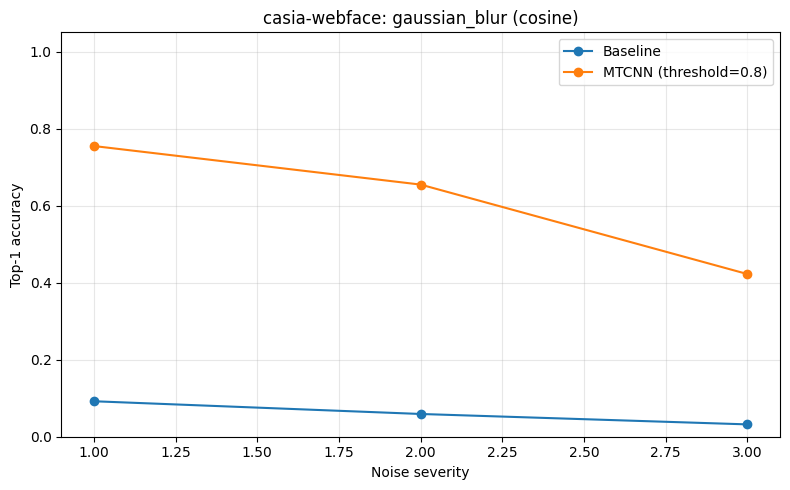

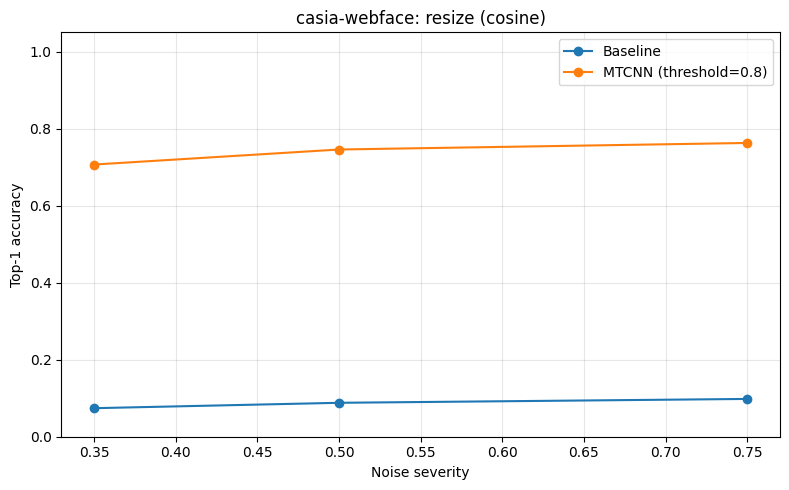

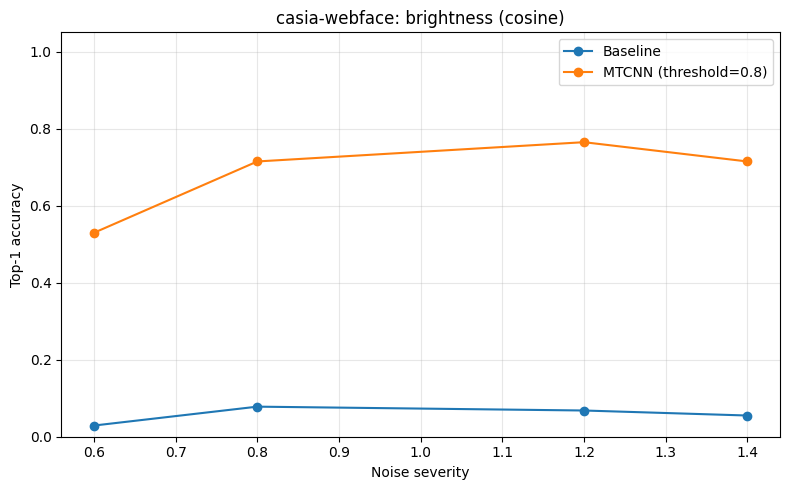

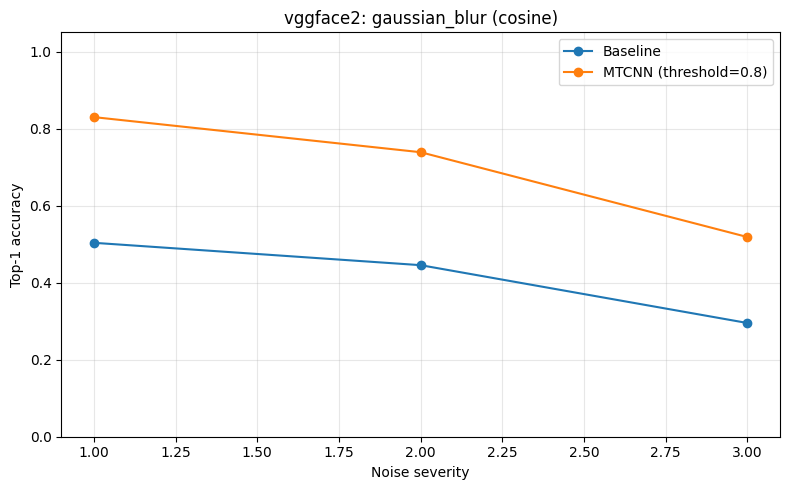

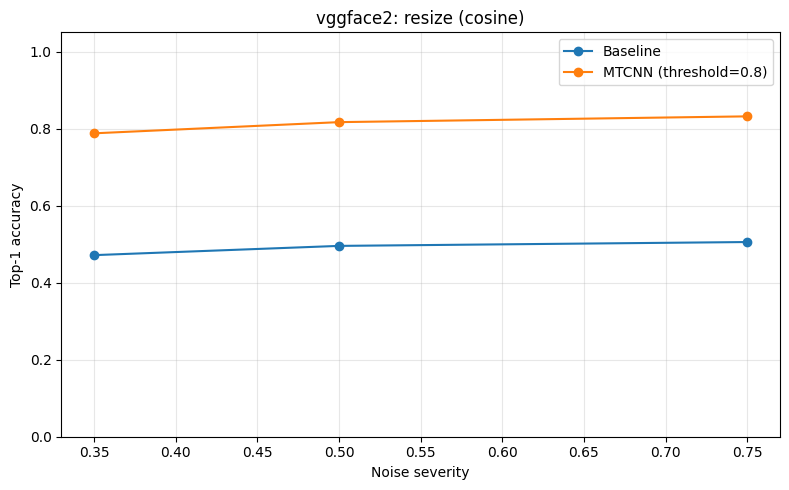

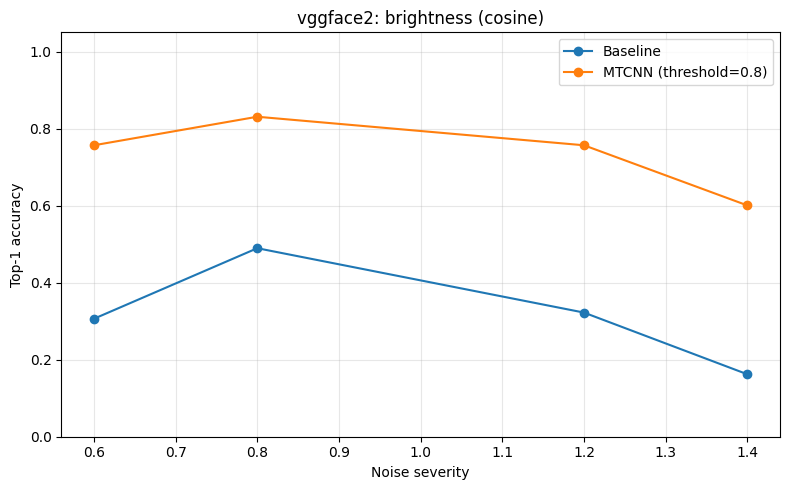

In [16]:
import matplotlib.pyplot as plt

def plot_baseline_vs_mtcnn_noise_separately(model_name: str, metric: str = "cosine"):
    sub = noise_df[
        (noise_df["model"] == model_name) &
        (noise_df["metric"] == metric)
    ].copy()

    baseline = sub[sub["variant"] == "baseline"].copy()
    mtcnn = sub[
        (sub["variant"] == "mtcnn_conf") &
        np.isclose(sub["conf_threshold"].astype(float), float(SELECTED_THRESHOLD))
    ].copy()

    for noise_type, levels in NOISE_PLAN.items():
        levels = [float(level) for level in levels]

        baseline_sub = baseline[baseline["noise_type"] == noise_type].copy()
        mtcnn_sub = mtcnn[mtcnn["noise_type"] == noise_type].copy()

        baseline_lookup = {
            float(r["noise_level"]): float(r["top1"])
            for _, r in baseline_sub.iterrows()
        }
        mtcnn_lookup = {
            float(r["noise_level"]): float(r["top1"])
            for _, r in mtcnn_sub.iterrows()
        }

        baseline_y = [baseline_lookup.get(level, np.nan) for level in levels]
        mtcnn_y = [mtcnn_lookup.get(level, np.nan) for level in levels]

        plt.figure(figsize=(8, 5))
        plt.plot(levels, baseline_y, marker="o", label="Baseline")
        plt.plot(
            levels,
            mtcnn_y,
            marker="o",
            label=f"MTCNN (threshold={float(SELECTED_THRESHOLD):g})"
        )
        plt.xlabel("Noise severity")
        plt.ylabel("Top-1 accuracy")
        plt.title(f"{model_name}: {noise_type} ({metric})")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

for _model in MODELS:
    plot_baseline_vs_mtcnn_noise_separately(_model, metric="cosine")

## Supplementary Minkowski section

This mirrors the enhanced Task 1 notebook's treatment of Minkowski as a supplementary metric.
It is disabled by default because it is slower and not part of the main exact Brute Force comparison.


In [17]:
# Optional supplementary Minkowski evaluation
# - keep clean Top-1 / Top-3 / Top-5
# - keep noisy Top-1 summary
# - DO NOT compute MRR for Minkowski

RUN_MINKOWSKI=True

if RUN_MINKOWSKI:
    from ironclad.modules.retrieval.search import FaissSearch

    def evaluate_minkowski_clean(model_name: str, variant: str, conf_threshold: float,
                                 p: int = 3, k_values=(1, 3, 5)) -> pd.DataFrame:
        gal_X = compute_embeddings(
            model_name, gallery_paths, "gallery_clean",
            variant, conf_threshold, "none", 0.0
        )
        prb_X = compute_embeddings(
            model_name, probe_paths, "probe_clean",
            variant, conf_threshold, "none", 0.0
        )

        bf = FaissBruteForce(dim=gal_X.shape[1], metric="euclidean")
        bf.add_embeddings(gal_X, gallery_labels)
        searcher = FaissSearch(bf, metric="minkowski", p=p)

        rows = []
        for k in k_values:
            correct = 0
            for q, true_lab in tqdm(
                list(zip(prb_X, probe_labels)),
                desc=f"Minkowski clean | {model_name} | {variant} | k={k}"
            ):
                _, _, meta = searcher.search(q, k=k)
                if true_lab in meta:
                    correct += 1

            rows.append({
                "model": model_name,
                "metric": "minkowski",
                "variant": variant,
                "conf_threshold": conf_threshold,
                "k": k,
                "accuracy": correct / len(probe_labels)
            })

        return pd.DataFrame(rows)

    def evaluate_minkowski_noisy_top1(model_name: str, variant: str, conf_threshold: float,
                                      noise_type: str, noise_level: float, p: int = 3) -> pd.DataFrame:
        gal_X = compute_embeddings(
            model_name, gallery_paths, "gallery_clean",
            variant, conf_threshold, "none", 0.0
        )
        prb_X = compute_embeddings(
            model_name, probe_paths, f"probe_{noise_type}_{noise_level}",
            variant, conf_threshold, noise_type, noise_level
        )

        bf = FaissBruteForce(dim=gal_X.shape[1], metric="euclidean")
        bf.add_embeddings(gal_X, gallery_labels)
        searcher = FaissSearch(bf, metric="minkowski", p=p)

        correct = 0
        for q, true_lab in tqdm(
            list(zip(prb_X, probe_labels)),
            desc=f"Minkowski noisy | {model_name} | {variant} | {noise_type}={noise_level}"
        ):
            _, _, meta1 = searcher.search(q, k=1)
            if true_lab in meta1:
                correct += 1

        return pd.DataFrame([{
            "model": model_name,
            "metric": "minkowski",
            "variant": variant,
            "conf_threshold": conf_threshold,
            "noise_type": noise_type,
            "noise_level": noise_level,
            "top1": correct / len(probe_labels)
        }])

    mink_clean_rows = []
    for model_name in MODELS:
        for variant, thr in VARIANTS:
            mink_clean_rows.append(
                evaluate_minkowski_clean(
                    model_name,
                    variant,
                    thr,
                    p=MINKOWSKI_P,
                    k_values=(1, 3, 5)
                )
            )
    mink_clean_df = pd.concat(mink_clean_rows, ignore_index=True)

    mink_noise_rows = []
    for model_name in MODELS:
        for variant, thr in VARIANTS:
            for noise_type, levels in NOISE_PLAN.items():
                for level in levels:
                    mink_noise_rows.append(
                        evaluate_minkowski_noisy_top1(
                            model_name,
                            variant,
                            thr,
                            noise_type,
                            float(level),
                            p=MINKOWSKI_P
                        )
                    )
    mink_noise_df = pd.concat(mink_noise_rows, ignore_index=True)

    # 1) Clean Top-k summary
    mink_clean_pivot = (
        mink_clean_df
        .pivot_table(
            index=["model", "metric", "variant", "conf_threshold"],
            columns="k",
            values="accuracy"
        )
        .reset_index()
        .rename(columns={1: "clean_top1", 3: "clean_top3", 5: "clean_top5"})
    )

    # 2) Noisy Top-1 summary
    mink_noisy_summary = (
        mink_noise_df
        .groupby(["model", "metric", "variant", "conf_threshold"], as_index=False)
        .agg(
            avg_noisy_top1=("top1", "mean"),
            worst_noisy_top1=("top1", "min")
        )
    )

    # 3) Final Minkowski summary
    mink_summary_df = (
        mink_clean_pivot
        .merge(
            mink_noisy_summary,
            on=["model", "metric", "variant", "conf_threshold"],
            how="left"
        )
        .sort_values(["model", "variant"])
        .reset_index(drop=True)
    )

    display(mink_summary_df)

    # 4) Winner table restricted to Minkowski
    mink_winner_rows = []
    for variant, thr in VARIANTS:
        sub = mink_summary_df[mink_summary_df["variant"] == variant]
        best = sub.sort_values(
            ["clean_top1", "avg_noisy_top1", "worst_noisy_top1"],
            ascending=False
        ).iloc[0]
        mink_winner_rows.append({
            "metric": "minkowski",
            "variant": variant,
            "winner_model": best["model"],
            "clean_top1": best["clean_top1"],
            "clean_top3": best["clean_top3"],
            "clean_top5": best["clean_top5"],
            "avg_noisy_top1": best["avg_noisy_top1"],
            "worst_noisy_top1": best["worst_noisy_top1"],
        })
    mink_winner_df = pd.DataFrame(mink_winner_rows)
    display(mink_winner_df)

    # 5) Optional combined summary table with the main exact metrics
    if "summary_df" in globals():
        summary_with_minkowski_df = pd.concat(
            [summary_df, mink_summary_df],
            ignore_index=True
        ).sort_values(["metric", "model", "variant"]).reset_index(drop=True)

        display(summary_with_minkowski_df)

else:
    print("RUN_MINKOWSKI = False — supplementary Minkowski section skipped.")

Minkowski clean | casia-webface | baseline | k=1:   0%|          | 0/999 [00:00<?, ?it/s]

Minkowski clean | casia-webface | baseline | k=3:   0%|          | 0/999 [00:00<?, ?it/s]

Minkowski clean | casia-webface | baseline | k=5:   0%|          | 0/999 [00:00<?, ?it/s]

Minkowski clean | casia-webface | mtcnn_conf | k=1:   0%|          | 0/999 [00:00<?, ?it/s]

Minkowski clean | casia-webface | mtcnn_conf | k=3:   0%|          | 0/999 [00:00<?, ?it/s]

...

Minkowski noisy | vggface2 | mtcnn_conf | brightness=1.2:   0%|          | 0/999 [00:00<?, ?it/s]

Minkowski noisy | vggface2 | mtcnn_conf | brightness=1.4:   0%|          | 0/999 [00:00<?, ?it/s]

,model,metric,variant,conf_threshold,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1
0,casia-webface,minkowski,baseline,0.9,0.092092,0.138138,0.161161,0.067668,0.029029
1,casia-webface,minkowski,mtcnn_conf,0.8,0.770771,0.833834,0.855856,0.675876,0.429429
2,vggface2,minkowski,baseline,0.9,0.507508,0.614615,0.664665,0.399499,0.160160
3,vggface2,minkowski,mtcnn_conf,0.8,0.844845,0.891892,0.902903,0.745546,0.516517


,metric,variant,winner_model,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1
0,minkowski,baseline,vggface2,0.507508,0.614615,0.664665,0.399499,0.160160
1,minkowski,mtcnn_conf,vggface2,0.844845,0.891892,0.902903,0.745546,0.516517


,model,metric,variant,conf_threshold,clean_top1,clean_top3,clean_top5,avg_noisy_top1,worst_noisy_top1,clean_mrr,avg_noisy_mrr,worst_noisy_mrr
0,casia-webface,cosine,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
1,casia-webface,cosine,mtcnn_conf,0.8,0.777778,0.833834,0.854855,0.677077,0.422422,0.812862,0.727908,0.512954
2,vggface2,cosine,baseline,0.9,0.506507,0.619620,0.664665,0.399700,0.162162,0.579554,0.475179,0.223738
3,vggface2,cosine,mtcnn_conf,0.8,0.842843,0.888889,0.900901,0.746847,0.518519,0.869199,0.790707,0.597200
4,casia-webface,dot_product,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
5,casia-webface,dot_product,mtcnn_conf,0.8,0.777778,0.833834,0.854855,0.677077,0.422422,0.812862,0.727908,0.512954
6,vggface2,dot_product,baseline,0.9,0.506507,0.619620,0.664665,0.399700,0.162162,0.579554,0.475179,0.223738
7,vggface2,dot_product,mtcnn_conf,0.8,0.842843,0.888889,0.900901,0.746847,0.518519,0.869199,0.790707,0.597200
8,casia-webface,euclidean,baseline,0.9,0.093093,0.137137,0.163163,0.067367,0.029029,0.133991,0.103789,0.058432
9,casia-webface,euclidean,mtcnn_conf,0.8,0.777778,0.833834,0.854855,0.677077,0.422422,0.812862,0.727908,0.512954
